<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# Lineare Regression – Beispiel: Körpergröße und Gehalt

Dieses Notebook zeigt an einem **synthetischen Beispiel**, wie lineare Regression funktioniert.

Wir untersuchen den (künstlichen) Zusammenhang zwischen:

- **Körpergröße (in cm)** – Eingangsvariable (Feature, \(x\))
- **Monatsgehalt (in €)** – Zielvariable (Target, \(y\))

Ziel:  
Ein Modell soll aus der Körpergröße das (erwartete) Gehalt vorhersagen.

In [8]:
# Falls nötig, Pakete installieren (auskommentiert lassen, wenn bereits vorhanden)
# !pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

## 1. Synthetische Daten erzeugen

Wir erzeugen einen Datensatz mit:

- ca. 80 Personen
- Körpergröße ~ Normalverteilung um 175 cm
- Gehalt hängt leicht von der Größe ab + zufälliges Rauschen

**WICHTIG:**  
Der Zusammenhang ist *nur* für Demonstrationszwecke und soll nicht die Realität widerspiegeln.

In [9]:
np.random.seed(42)
n_samples = 80

# Körpergröße in cm (Normalverteilung um 175 cm, Streuung 10 cm)
height_cm = np.random.normal(loc=175, scale=10, size=n_samples)

# Gehalt in Euro (leichte Abhängigkeit von der Größe + Rauschen)
base_salary = 3000        # Basisgehalt
slope = 15                # Gehaltszuwachs pro cm (künstlich gewählt)
noise = np.random.normal(loc=0, scale=200, size=n_samples)  # Rauschen

salary_eur = base_salary + slope * (height_cm - 175) + noise

df = pd.DataFrame({
    "height_cm": height_cm,
    "salary_eur": salary_eur
})

df.head()

,height_cm,salary_eur
0,179.967142,3030.572745
1,173.617357,3050.682869
2,181.476885,3392.732090
3,190.230299,3124.800435
4,172.658466,2803.178273


## 2. Daten visualisieren

Wir schauen uns die Punktwolke an:

- Jeder Punkt = eine Person
- x-Achse: Körpergröße
- y-Achse: Gehalt

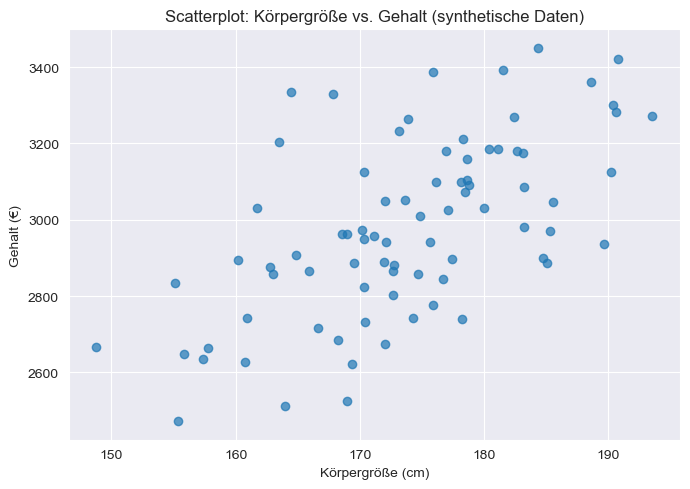

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(df["height_cm"], df["salary_eur"], alpha=0.7)
plt.xlabel("Körpergröße (cm)")
plt.ylabel("Gehalt (€)")
plt.title("Scatterplot: Körpergröße vs. Gehalt (synthetische Daten)")
plt.tight_layout()
plt.show()

## 3. Lineares Regressionsmodell trainieren

Wir verwenden `LinearRegression` aus `scikit-learn`.

Modellform:

\[
\text{Gehalt} = a \cdot \text{Körpergröße} + b
\]

Wir lassen das Modell die Parameter \(a\) (Steigung) und \(b\) (Bias) lernen.

In [4]:
# Feature-Matrix und Zielvektor
X = df[["height_cm"]]   # 2D-Array
y = df["salary_eur"]    # 1D-Array

model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_

print(f"Steigung a: {a:.2f} € pro cm")
print(f"Bias b: {b:.2f} € (theoretisches Gehalt bei 0 cm – nur mathematisch)")

Steigung a: 14.79 € pro cm
Bias b: 409.02 € (theoretisches Gehalt bei 0 cm – nur mathematisch)


## 4. Vorhersagen & Modellgüte

Wir berechnen:

- Vorhergesagte Gehälter für alle Personen
- Fehlermaß: **Mean Squared Error (MSE)**
- **R²-Score** als Maß für Erklärungsgehalt des Modells

In [5]:
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R²-Score: {r2:.3f}")

Mean Squared Error (MSE): 33255.46
R²-Score: 0.373


## 5. Regressionslinie visualisieren

Wir zeichnen:

- Originaldaten (Punkte)
- die **best-fit-Gerade** des Modells

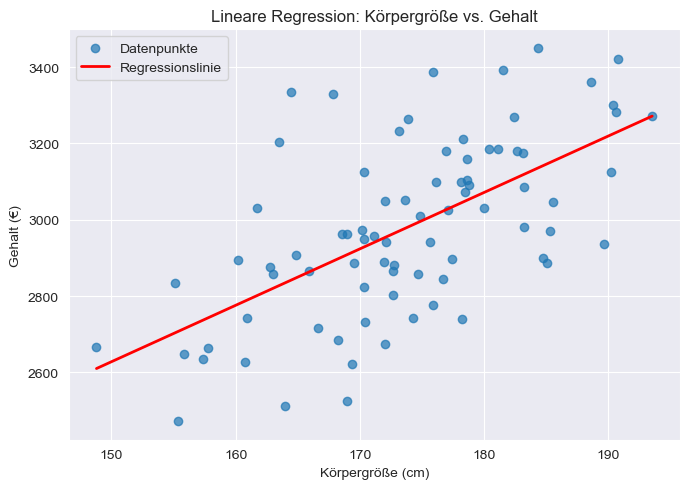

In [6]:
# Linie über den Bereich der Körpergrößen aufspannen
x_line = np.linspace(df["height_cm"].min(), df["height_cm"].max(), 100).reshape(-1, 1)
x_line = pd.DataFrame(x_line, columns=["height_cm"])
y_line = model.predict(x_line)

plt.figure(figsize=(7, 5))
plt.scatter(df["height_cm"], df["salary_eur"], alpha=0.7, label="Datenpunkte")
plt.plot(x_line, y_line, color="red", label="Regressionslinie", linewidth=2)

plt.xlabel("Körpergröße (cm)")
plt.ylabel("Gehalt (€)")
plt.title("Lineare Regression: Körpergröße vs. Gehalt")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Beispielvorhersage

Was würde das Modell z. B. für eine Person mit **180 cm** Körpergröße vorhersagen?

In [7]:
height_example = pd.DataFrame([[176]], columns=["height_cm"])
salary_pred = model.predict(height_example)[0]

print(f"Vorhersage für 180 cm Körpergröße: {salary_pred:.2f} €")

Vorhersage für 180 cm Körpergröße: 3012.26 €


## 7. Fazit

In diesem Notebook haben wir gesehen:

- Wie man **synthetische Daten** für ein Regressionsbeispiel erzeugt  
- Wie eine **lineare Regression** mit `scikit-learn` trainiert wird  
- Wie man **Steigung, Bias, MSE und R²** interpretiert  
- Wie man das Ergebnis in einem **Diagramm** visualisiert  

Dieses Beispiel ist bewusst vereinfacht und künstlich – in der Realität hängt Gehalt von vielen Faktoren ab (Ausbildung, Branche, Erfahrung usw.).  
Aber genau deshalb eignet es sich sehr gut, um das Prinzip der Regression zu verstehen.
